<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_12_Regression_Machine_Learning_Case_Study_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12: Regression Machine Learning Case Study Project

How do you work through a predictive modeling machine learning problem end-to-end? In this
lesson you will work through a case study regression predictive modeling problem in Python
including each step of the applied machine learning process. After completing this project, you
will know:
- How to work through a regression predictive modeling problem end-to-end.
- How to use data transforms to improve model performance.
- How to use algorithm tuning to improve model performance.
- How to use ensemble methods and tuning of ensemble methods to improve model performance.

## Problem Definition

For this project, we will investigate a synthetic Naval Maintenance dataset. Each record in the dataset represents a cargo ship and its technical and operational characteristics. The data simulates realistic information commonly found in the maritime engineering field, focusing on factors that influence a vessel's annual maintenance cost. The attributes are defined as follows:

- **FUEL_CONSUMP**: Average daily fuel consumption (in tons per day).
- **CARGO_CAPACITY**: Maximum cargo capacity (in thousand metric tons).
- **ENGINE_POWER**: Main engine power output (in megawatts).
- **HAS_DUAL_PROP**: Binary indicator of whether the vessel has a dual propeller system (0 = no, 1 = yes).
- **NOX_EMISSIONS**: Emissions of nitrogen oxides from the engine (in grams per kilowatt-hour).
- **CREW_SIZE**: Average number of crew members on board.
- **AGE_YEARS**: Age of the vessel (in years since commissioning).
- **PORT_DISTANCE**: Average distance to the vessel’s home port during operation (in nautical miles).
- **NAV_EQUIP_LEVEL**: Level of onboard navigation and electronic systems (scale from 1 to 10).
- **REG_FEES**: Annual registration and compliance fees (in thousands of USD).
- **MAINT_CREW_RATIO**: Ratio of maintenance personnel to total crew.
- **PAINT_COVERAGE**: Index representing the quality and coverage of anti-corrosive coating (scale 0–100).
- **RUST_AREA_PERCENT**: Percentage of the ship’s surface area affected by active corrosion or rust.
- **MAINT_COST**: **Target variable** — Estimated annual maintenance cost for the vessel (in thousands of USD).




## Load The Data
In this step we are going to load the libraries and the naval data CSV file from URL.

---
**Load libraries**

---

In [4]:
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

---
**Load Dataset**

---

We can now load the dataset that you can download from the URL

In [8]:
!wget -O /content/sample_data/Naval_Maintenance_Dataset.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Maintenance_Dataset.csv

--2025-04-09 11:15:23--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Maintenance_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35400 (35K) [text/plain]
Saving to: ‘/content/sample_data/Naval_Maintenance_Dataset.csv’

/content/sample_dat 100%[===================>]  34.57K  --.-KB/s    in 0.01s   

2025-04-09 11:15:23 (3.31 MB/s) - ‘/content/sample_data/Naval_Maintenance_Dataset.csv’ saved [35400/35400]



In [13]:
# Load the dataset
filename = '/content/sample_data/Naval_Maintenance_Dataset.csv'

# Define short column names
names = [
    'FUEL', 'CAP', 'ENG_POW', 'DUAL',
    'NOX', 'CREW', 'AGE', 'DIST',
    'NAV', 'FEES', 'M_RATIO', 'PAINT',
    'RUST', 'COST'
]
data = read_csv(filename, names=names, header=0)
array = data.values

You can see that we are specifying the short names for each attribute so that we can reference
them clearly later. You can also see that attributes are delimited by whitespace rather than
commas in this file and we indicate this to `read csv()` function via the delim whitespace
argument. We now have our data loaded.

## Summarize the Dataset

We can now take a closer look at our loaded data. We can get a quick idea of how many instances (rows) and how many attributes (columns) the
data contains with the shape property.

---
**Data Shape**

---

In [15]:
# shape
print(data.shape)

(506, 14)


We have 506 instances to work with and can confirm the data has 14 attributes.

Let’s also look at the data types of each attribute.

In [16]:
# types
print(data.dtypes)

FUEL       float64
CAP        float64
ENG_POW    float64
DUAL         int64
NOX        float64
CREW       float64
AGE        float64
DIST       float64
NAV          int64
FEES       float64
M_RATIO    float64
PAINT      float64
RUST       float64
COST       float64
dtype: object


---
**Show first rows**

---

It is also always a good idea to actually eyeball your data.

In [17]:
# head
print(data.head(20))

     FUEL   CAP  ENG_POW  DUAL   NOX  CREW   AGE   DIST  NAV   FEES  M_RATIO  \
0   34.97  38.2    35.38     0  4.35  21.0  17.9   51.5    7  21.74     0.13   
1   28.62  32.7    21.55     0  6.13  30.0  15.7  185.4    3  22.49     0.24   
2   36.48  51.0    33.68     1  5.29  29.0  26.9  112.0    6  13.84     0.10   
3   45.23  33.4    25.99     1  5.48  24.0  13.8  164.4    4   8.37     0.17   
4   27.66  55.4    21.74     0  6.33  32.0  13.2  226.8    3  21.83     0.22   
5   27.66  49.0    22.58     0  4.21  23.0  10.2  117.2    9  14.74     0.14   
6   45.79  45.2    23.40     0  5.99  23.0  18.4  131.1   10  14.21     0.23   
7   37.67  31.8    27.12     1  4.42   8.0  18.1  163.8    2  10.54     0.16   
8   25.31  38.5    27.61     1  5.51  27.0   8.3   85.1    1   8.75     0.14   
9   35.43  65.1    22.13     1  4.03  18.0  13.2  112.1    2  17.82     0.26   
10  25.37  60.0    24.88     1  3.63  22.0   8.4  151.2    7  18.35     0.21   
11  25.34  30.4    35.71     0  5.14  20

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.



In [18]:
# Statistical Summary
print(pd.DataFrame(data).describe())

             FUEL         CAP     ENG_POW        DUAL         NOX        CREW  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    30.084684   50.847628   25.472925    0.525692    4.934881   25.274704   
std      9.829086   19.450796    5.053316    0.499834    1.505854    4.920118   
min     -2.410000   -3.900000   10.520000    0.000000    0.750000    8.000000   
25%     23.017500   38.500000   21.970000    0.000000    3.930000   22.000000   
50%     30.130000   50.950000   25.385000    1.000000    4.955000   26.000000   
75%     36.422500   63.425000   28.667500    1.000000    5.937500   29.000000   
max     68.530000  102.600000   38.010000    1.000000    9.100000   40.000000   

              AGE        DIST         NAV        FEES     M_RATIO       PAINT  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    14.350000  150.436759    5.660079   14.964506    0.198755   85.033992   
std      9.705647   50.7863

We can confirm that the scales for the attributes are all over the place because of the differing
units. We may benefit from some transforms later on.

---
**Change Display Precision**

---

In [21]:
# Change Display Precision
pd.set_option('display.precision', 1)
print(data.describe())

        FUEL    CAP  ENG_POW   DUAL    NOX   CREW    AGE   DIST    NAV   FEES  \
count  506.0  506.0    506.0  506.0  506.0  506.0  506.0  506.0  506.0  506.0   
mean    30.1   50.8     25.5    0.5    4.9   25.3   14.4  150.4    5.7   15.0   
std      9.8   19.5      5.1    0.5    1.5    4.9    9.7   50.8    3.0    4.9   
min     -2.4   -3.9     10.5    0.0    0.8    8.0  -18.2   13.9    1.0    0.3   
25%     23.0   38.5     22.0    0.0    3.9   22.0    8.0  115.5    3.0   11.8   
50%     30.1   51.0     25.4    1.0    5.0   26.0   13.8  151.1    6.0   14.9   
75%     36.4   63.4     28.7    1.0    5.9   29.0   21.2  186.7    8.0   18.2   
max     68.5  102.6     38.0    1.0    9.1   40.0   41.8  288.3   10.0   28.8   

       M_RATIO  PAINT   RUST   COST  
count  5.1e+02  506.0  506.0  506.0  
mean   2.0e-01   85.0   12.4  171.7  
std    4.9e-02   10.2    6.9   35.1  
min    1.0e-02   56.2   -9.4   65.4  
25%    1.7e-01   77.9    7.5  147.2  
50%    2.0e-01   85.3   12.6  171.7  
75% 

We now have a better feeling for how different the attributes are. The min and max values
as well are the means vary a lot. We are likely going to get better results by rescaling the data
in some way.



---
**Correlation**

---

Now, let’s now take a look at the correlation between all of the numeric attributes.

In [22]:
# correlation
pd.set_option('display.precision', 2)
print(data.corr(method='pearson'))

         FUEL       CAP   ENG_POW      DUAL       NOX      CREW       AGE  \
FUEL     1.00  1.01e-01 -8.60e-02  2.92e-02  6.55e-02 -7.93e-02  4.87e-02   
CAP      0.10  1.00e+00 -3.74e-02 -1.30e-02 -7.86e-03  5.77e-03  2.88e-02   
ENG_POW -0.09 -3.74e-02  1.00e+00 -8.19e-03 -6.57e-03  4.11e-02  3.31e-02   
DUAL     0.03 -1.30e-02 -8.19e-03  1.00e+00  2.69e-03 -3.71e-02  8.16e-02   
NOX      0.07 -7.86e-03 -6.57e-03  2.69e-03  1.00e+00  9.17e-03 -5.73e-02   
CREW    -0.08  5.77e-03  4.11e-02 -3.71e-02  9.17e-03  1.00e+00 -1.09e-02   
AGE      0.05  2.88e-02  3.31e-02  8.16e-02 -5.73e-02 -1.09e-02  1.00e+00   
DIST     0.02 -1.93e-03 -3.36e-02 -9.08e-02  2.37e-02 -7.23e-02 -3.88e-02   
NAV     -0.01 -4.70e-04  3.22e-02  1.25e-02  2.81e-02  3.27e-03 -7.59e-03   
FEES    -0.05  1.53e-02 -1.33e-02 -9.91e-03  1.16e-02  3.81e-02 -1.94e-02   
M_RATIO  0.04  3.83e-02 -5.17e-02  9.08e-04 -1.38e-02 -6.05e-02 -4.81e-02   
PAINT   -0.02  2.38e-02  5.44e-02 -1.33e-03  1.60e-02  5.78e-02  2.85e-02   

En formato de salida modo texto es complicado visualizar las correlaciones mas fuertes.

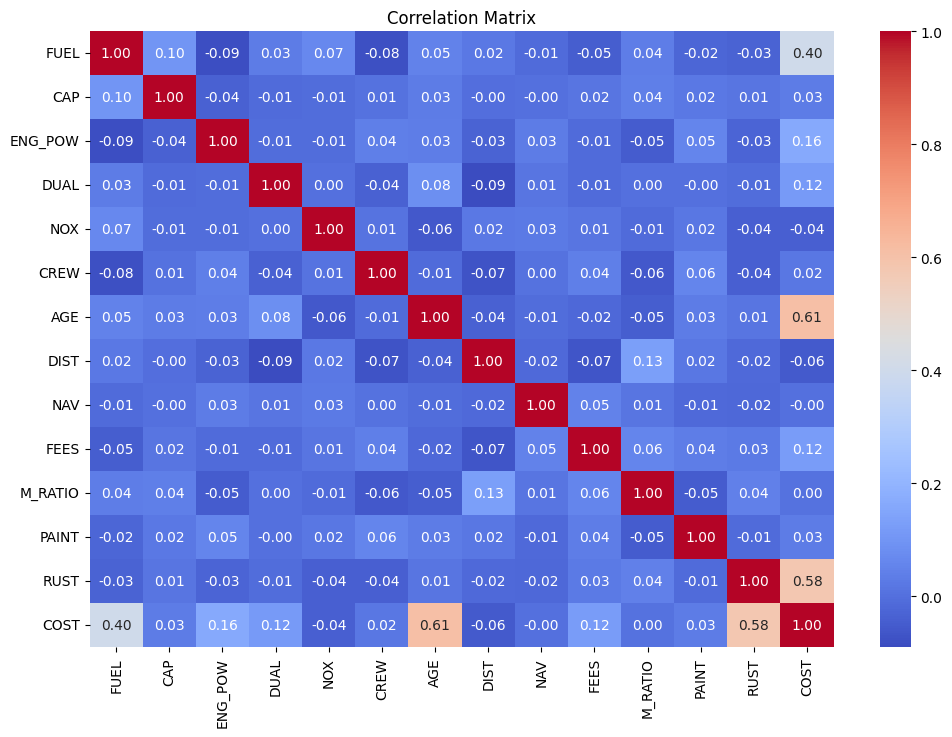

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

The dark red color shows positive correlation whereas the dark blue color shows negative
correlation. We can also see some dark red and dark blue that suggest candidates for removal
to better improve accuracy of models later on.

There are **2 attributes** with a strong correlation to the target variable `COST` (correlation > 0.5):

- **AGE**: Correlation = **0.612**
- **RUST**: Correlation = **0.582**

The strong correlation between COST, AGE, and RUST suggests that these features can significantly influence the maintenance cost of vessels. Understanding and using these relationships can help improve maintenance schedules, cost predictions, and overall operational strategies.


## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: Histogram**

---

Let’s look at visualizations of individual attributes. It is often useful to look at your data
using multiple different visualizations in order to spark ideas. Let’s look at histograms of each
attribute to get a sense of the data distributions.

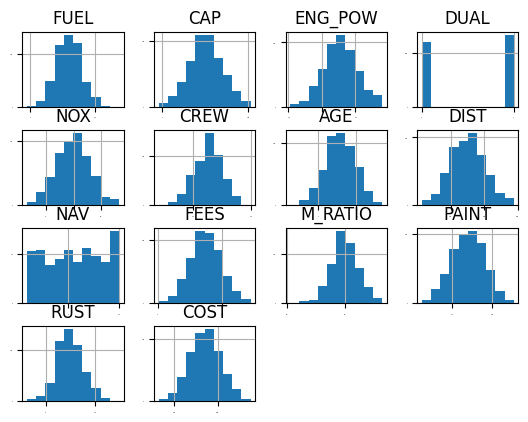

In [25]:
# histograms
data.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
pyplot.show()

| Variable   | Possible Histogram Distribution                                                                 |
|------------|-------------------------------------------------------------------------------------------------|
| **FUEL**   | Symmetric (typical consumption around the mean) or right-skewed (a few high values).            |
| **NOX**    | Right-skewed (most emissions low, few high outliers).                                           |
| **NAV**    | Right-skewed (high-value assets are rare).                                                      |
| **RUST**   | Left-skewed (most cases show little rust).                                                      |
| **CAP**    | Symmetric (standardized capacity) or bimodal (two dominant capacity groups).                    |
| **CREW**   | Discrete (integer bars) with a clear mode (e.g., 4 people).                                     |
| **FEES**   | Right-skewed (mostly low fees, a few very high).                                                |
| **COST**   | Similar to FEES; right-skewed due to occasional high costs.                                     |
| **ENG_POW**| Symmetric (standardized engines) or skewed (varied power outputs).                              |
| **AGE**    | Right-skewed (many new, few old) or uniform (evenly distributed).                               |
| **M_RATIO**| Centered around a value (if optimized) or multimodal (multiple operating modes).                |
| **DUAL**   | Binary discrete (two bars: 0 and 1 for non-dual/dual systems).                                  |
| **PAINT**  | Ordinal (e.g., 1-5 scale), possibly left-skewed (good condition) or uniform.                    |


**Why Skewed Gaussian Distributions Are Problematic**

1. Many algorithms (e.g., linear regression, Gaussian Naive Bayes, PCA) assume data is normally distributed. Skew violates this assumption, leading to biased results.

2. Models like logistic regression and SVMs may underperform if features have heavy tails or outliers. Skewed data often has outliers, which can disproportionately influence model training (e.g., MSE loss in regression).

---
**Univariate Plots: Density**

---


Let’s look at the same distributions using density plots that smooth them out a bit.

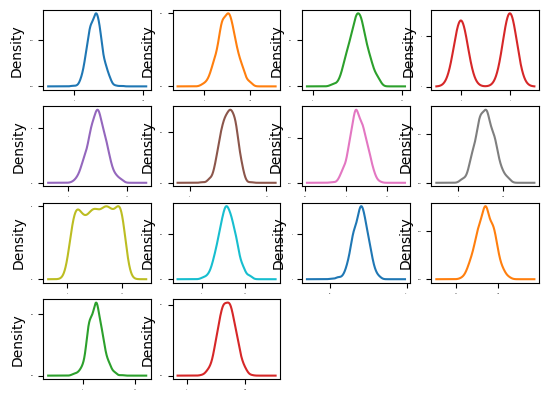

In [26]:
# density
data.plot(kind='density', subplots=True, layout=(4,4), sharex=False, legend=False,
fontsize=1)
pyplot.show()

---
**Univariate Plots: Whisker Plot**

---

Let’s look at the data with box and whisker plots of each attribute.

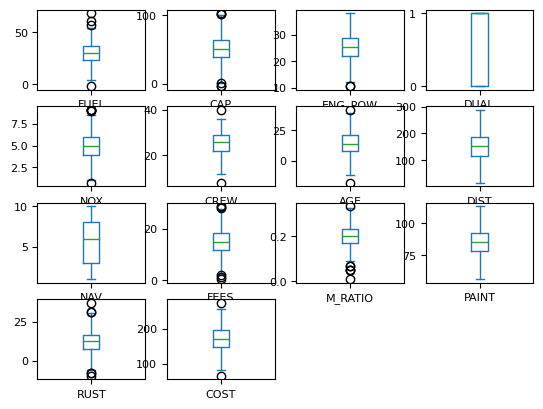

In [27]:
# box and whisker plots
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False,
fontsize=8)
pyplot.show()

This helps point out the skew in many distributions so much so that data looks like outliers
(e.g. beyond the whisker of the plots).

---
**Multivariate Plots: scatter plot**

---

Now we can look at the interactions between the variables. Let’s look at scatter plots of all
pairs of attributes. This can be helpful to spot structured relationships between input variables.

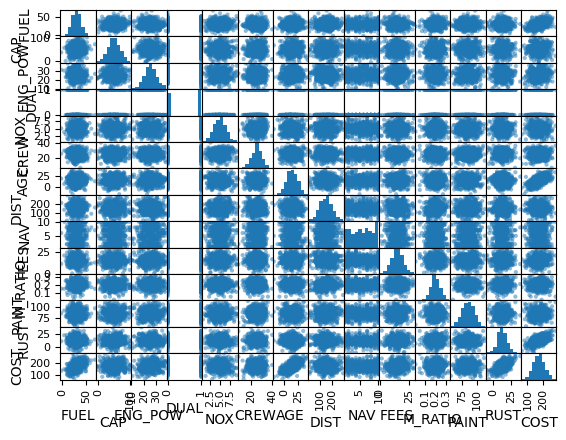

In [28]:
# scatter plot matrix
scatter_matrix(pd.DataFrame(data))
plt.show()

We can see that some of the higher correlated attributes (as we have already seen when we visualised the correlations) do show good structure in their
relationship. Not linear, but nice predictable curved relationships.

## Evaluate Some Algorithms

Now it is time to create some models of the data and estimate their accuracy on unseen data.
Here is what we are going to cover in this step:
1. Separate out a validation dataset.
2. Setup the test harness to use 10-fold cross validation.
3. Build 6 different models for this regression problem
4. Select the best model.

### Create a Validation Dataset

It is a good idea to use a validation hold-out set. This is a sample of the data that we hold
back from our analysis and modeling. We use it right at the end of our project to confirm the
accuracy of our final model. It is a smoke test that we can use to see if we messed up and to give us confidence on our estimates of accuracy on unseen data. We will use 80% of the dataset
for modeling and hold back 20% for validation.

---
**Split-out validation dataset**

---

In [29]:
# Split-out validation dataset
array = data.values
X = array[:,0:13]
Y = array[:,13]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

You now have training data in the `X train` and `Y train` for preparing models and a
`X validation` and `Y validation` sets that we can use later.

### Baseline Evaluation

We have no idea what algorithms will do well on this problem. Gut feel suggests regression
algorithms like Linear Regression and ElasticNet may do well. It is also possible that decision
trees and even SVM may do well. I have no idea. Let’s design our test harness. We will use
10-fold cross validation. The dataset is not too small and this is a good standard test harness
configuration. We will evaluate algorithms using the Mean Squared Error (MSE) metric. MSE
will give a gross idea of how wrong all predictions are (0 is perfect).

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples (same as Boston dataset)
n_samples = 506

# Generate synthetic data (based on plausible naval engineering ranges)
data = {
    "FUEL_CONSUMP": np.round(np.random.normal(loc=30, scale=10, size=n_samples), 2),  # tons/day
    "CARGO_CAPACITY": np.round(np.random.normal(loc=50, scale=20, size=n_samples), 1),  # thousand tons
    "ENGINE_POWER": np.round(np.random.normal(loc=25, scale=5, size=n_samples), 2),  # MW
    "HAS_DUAL_PROP": np.random.choice([0, 1], size=n_samples),  # 0 or 1
    "NOX_EMISSIONS": np.round(np.random.normal(loc=5.0, scale=1.5, size=n_samples), 2),  # g/kWh
    "CREW_SIZE": np.round(np.random.normal(loc=25, scale=5, size=n_samples), 0),  # number of crew
    "AGE_YEARS": np.round(np.random.normal(loc=15, scale=10, size=n_samples), 1),  # years
    "PORT_DISTANCE": np.round(np.random.normal(loc=150, scale=50, size=n_samples), 1),  # NM
    "NAV_EQUIP_LEVEL": np.random.randint(1, 11, size=n_samples),  # scale 1 to 10
    "REG_FEES": np.round(np.random.normal(loc=15, scale=5, size=n_samples), 2),  # thousands USD
    "MAINT_CREW_RATIO": np.round(np.random.normal(loc=0.2, scale=0.05, size=n_samples), 2),  # ratio
    "PAINT_COVERAGE": np.round(np.random.normal(loc=85, scale=10, size=n_samples), 1),  # index 0–100
    "RUST_AREA_PERCENT": np.round(np.random.normal(loc=12, scale=7, size=n_samples), 2),  # %
}

# Generate the target variable (MAINT_COST) based on a weighted combination + noise
# This simulates a plausible regression target
weights = {
    "FUEL_CONSUMP": 1.5,
    "AGE_YEARS": 2.0,
    "ENGINE_POWER": 1.2,
    "RUST_AREA_PERCENT": 3.0,
    "CREW_SIZE": 0.5,
    "HAS_DUAL_PROP": 5.0,
    "REG_FEES": 1.0
}
noise = np.random.normal(0, 10, n_samples)

# Calculate maintenance cost (in thousands USD)
maint_cost = (
    weights["FUEL_CONSUMP"] * data["FUEL_CONSUMP"] +
    weights["AGE_YEARS"] * data["AGE_YEARS"] +
    weights["ENGINE_POWER"] * data["ENGINE_POWER"] +
    weights["RUST_AREA_PERCENT"] * data["RUST_AREA_PERCENT"] +
    weights["CREW_SIZE"] * data["CREW_SIZE"] +
    weights["HAS_DUAL_PROP"] * data["HAS_DUAL_PROP"] +
    weights["REG_FEES"] * data["REG_FEES"] +
    noise
)

# Add target to data
data["MAINT_COST"] = np.round(maint_cost, 2)

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("naval_maintenance_dataset.csv", index=False)

print("Dataset saved as 'naval_maintenance_dataset.csv'")


Dataset saved as 'naval_maintenance_dataset.csv'
